#Imports des librairies et chargement du dataset

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import plotly as pt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df_CduS= pd.read_csv("/content/drive/MyDrive/PARIS 0224 - Data Analyst/Projets/projet3/Vital Stats - Hadi, Sylvain, Henri, Khadija, Erwan/Cancer du Sein/df_CduS.csv", sep = ",")

In [ ]:
df_CduS.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
numeric_columns = df_CS.columns[1:-1]

for c in numeric_columns:
  print(f"Statistiques pour la colonne {c} selon les valeurs de 'diagnosis':\n")
  grouped = df_CduS.groupby("diagnosis")[c].describe(percentiles = np.arange(0, 1, 0.1))
  print(grouped.to_markdown())
  print("\n")


Statistiques pour la colonne radius_mean selon les valeurs de 'diagnosis':

| diagnosis   |   count |    mean |     std |    min |     0% |     10% |    20% |    30% |    40% |    50% |    60% |    70% |    80% |    90% |   max |
|:------------|--------:|--------:|--------:|-------:|-------:|--------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|------:|
| B           |     357 | 12.1465 | 1.78051 |  6.981 |  6.981 |  9.7266 | 10.67  | 11.318 | 11.722 | 12.2   | 12.662 | 13.05  | 13.648 | 14.452 | 17.85 |
| M           |     212 | 17.4628 | 3.20397 | 10.95  | 10.95  | 13.61   | 14.616 | 15.46  | 16.244 | 17.325 | 18.286 | 19.204 | 20.154 | 21.075 | 28.11 |


Statistiques pour la colonne texture_mean selon les valeurs de 'diagnosis':

| diagnosis   |   count |    mean |     std |   min |    0% |    10% |    20% |    30% |    40% |   50% |    60% |    70% |    80% |    90% |   max |
|:------------|--------:|--------:|--------:|------:|------:|-------:|-------:|

In [ ]:
df_CS = df_CduS.copy()

#Corrélations sur l'ensemble du dataset

<ipython-input-86-5480789704a5>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_CS, x='diagnosis', palette=[couleur_M, couleur_B])


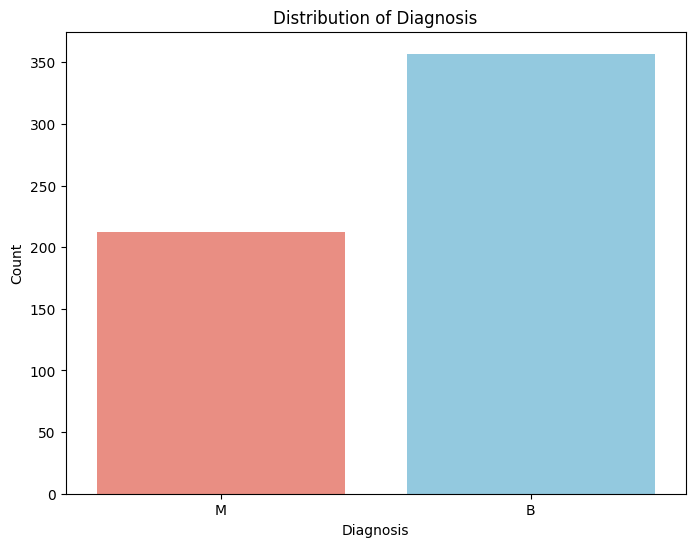

In [ ]:
# Distribution of the target variable 'diagnosis'
couleur_B = "skyblue"
couleur_M = "salmon"

plt.figure(figsize=(8, 6))
sns.countplot(data=df_CS, x='diagnosis', palette=[couleur_M, couleur_B])
plt.title('Distribution of Diagnosis')
plt.xlabel('Diagnosis')
plt.ylabel('Count')
plt.show()

In [ ]:
df_CS["diagnosis"] = df_CS["diagnosis"].map({"M": 1, "B": 0})

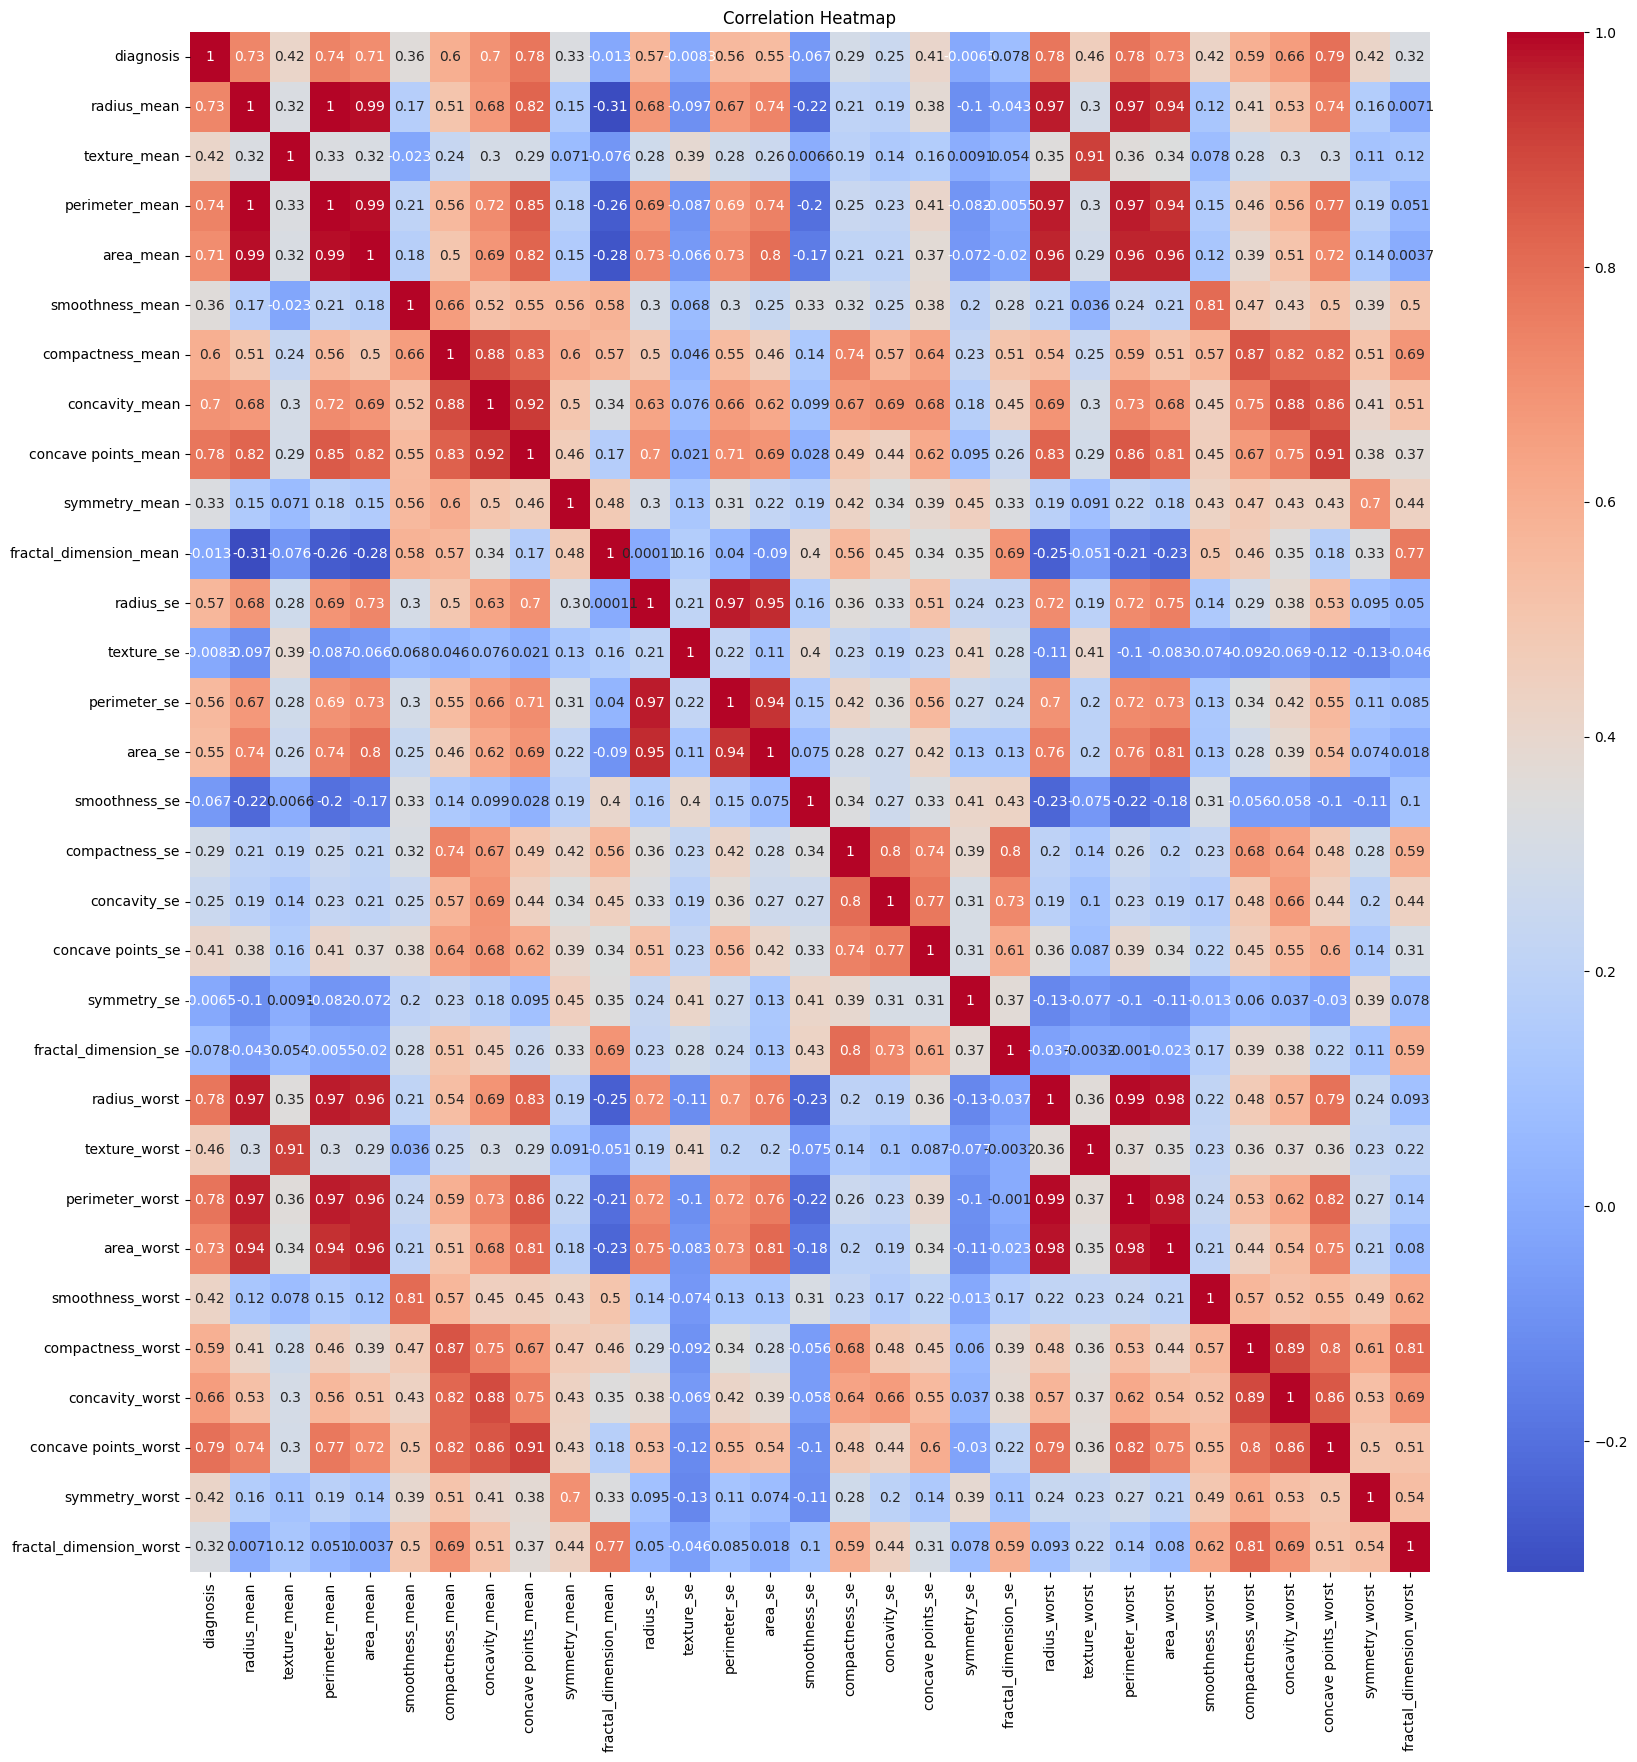

In [ ]:
#sans_col = ["diagnosis"]
#data = df_CS.loc[:, ~df_CS.columns.isin(sans_col)]
correlation_matrix = df_CS.corr()

plt.figure(figsize = (20,20))

sns.heatmap(correlation_matrix, cmap="coolwarm", annot = True)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
correlation_matrix

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.730029,0.415185,0.742636,0.708984,0.358560,0.596534,0.696360,0.776614,0.330499,...,0.776454,0.456903,0.782914,0.733825,0.421465,0.590998,0.659610,0.793566,0.416294,0.323872
radius_mean,0.730029,1.000000,0.323782,0.997855,0.987357,0.170581,0.506124,0.676764,0.822529,0.147741,...,0.969539,0.297008,0.965137,0.941082,0.119616,0.413463,0.526911,0.744214,0.163953,0.007066
texture_mean,0.415185,0.323782,1.000000,0.329533,0.321086,-0.023389,0.236702,0.302418,0.293464,0.071401,...,0.352573,0.912045,0.358040,0.343546,0.077503,0.277830,0.301025,0.295316,0.105008,0.119205
perimeter_mean,0.742636,0.997855,0.329533,1.000000,0.986507,0.207278,0.556936,0.716136,0.850977,0.183027,...,0.969476,0.303038,0.970387,0.941550,0.150549,0.455774,0.563879,0.771241,0.189115,0.051019
area_mean,0.708984,0.987357,0.321086,0.986507,1.000000,0.177028,0.498502,0.685983,0.823269,0.151293,...,0.962746,0.287489,0.959120,0.959213,0.123523,0.390410,0.512606,0.722017,0.143570,0.003738
smoothness_mean,0.358560,0.170581,-0.023389,0.207278,0.177028,1.000000,0.659123,0.521984,0.553695,0.557775,...,0.213120,0.036072,0.238853,0.206718,0.805324,0.472468,0.434926,0.503053,0.394309,0.499316
compactness_mean,0.596534,0.506124,0.236702,0.556936,0.498502,0.659123,1.000000,0.883121,0.831135,0.602641,...,0.535315,0.248133,0.590210,0.509604,0.565541,0.865809,0.816275,0.815573,0.510223,0.687382
concavity_mean,0.696360,0.676764,0.302418,0.716136,0.685983,0.521984,0.883121,1.000000,0.921391,0.500667,...,0.688236,0.299879,0.729565,0.675987,0.448822,0.754968,0.884103,0.861323,0.409464,0.514930
concave points_mean,0.776614,0.822529,0.293464,0.850977,0.823269,0.553695,0.831135,0.921391,1.000000,0.462497,...,0.830318,0.292752,0.855923,0.809630,0.452753,0.667454,0.752399,0.910155,0.375744,0.368661
symmetry_mean,0.330499,0.147741,0.071401,0.183027,0.151293,0.557775,0.602641,0.500667,0.462497,1.000000,...,0.185728,0.090651,0.219169,0.177193,0.426675,0.473200,0.433721,0.430297,0.699826,0.438413


##Interprétation de la matrice de corrélation

La matrice de corrélation nous permet d'identifier de fortes corrélations positives entre variables

ex: radius_mean avec perimeter_mean, area_mean, concave points_mean, radius_worst, perimeter_worst, area_worst

En revanche, on ne note que de faibles corrélations négatives